In [1]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully ✓")

All libraries imported successfully ✓


In [2]:
ticker = "AAPL"

data = yf.download(ticker, start="2022-01-01", end="2025-01-01", auto_adjust=True)

data.columns = [col[0] for col in data.columns]

data.columns = ["close", "high", "low", "open", "volume"]

print(f"Downloaded {ticker} stock data")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Total trading days: {len(data)}")
print("\nFirst 3 rows:")
data.head(3)

[*********************100%***********************]  1 of 1 completed

Downloaded AAPL stock data
Date range: 2022-01-03 to 2024-12-31
Total trading days: 753

First 3 rows:


,close,high,low,open,volume
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843246,179.013714,175.275693,178.710370,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600


In [3]:
## Add technical indicators
# RSI - momentum oscillator (0 to 100)
data["rsi"] = ta.rsi(data["close"], length=14)

# MACD - trend momentum
macd = ta.macd(data["close"], fast=12, slow=26, signal=9)
data["macd"]        = macd["MACD_12_26_9"]
data["macd_signal"] = macd["MACDs_12_26_9"]

# EMA ratio - short vs long term trend
data["ema9"]      = ta.ema(data["close"], length=9)
data["ema21"]     = ta.ema(data["close"], length=21)
data["ema_ratio"] = data["ema9"] / data["ema21"]

# Bollinger Bands %B - price position in volatility range
bbands = ta.bbands(data["close"], length=20, std=2)
data["bb_percent"] = bbands["BBP_20_2.0_2.0"]

# ATR - market volatility
data["atr"] = ta.atr(data["high"], data["low"], data["close"], length=14)

# Volume ratio - unusual activity signal
data["volume_ratio"] = data["volume"] / data["volume"].rolling(10).mean()

print("Technical indicators added ✓")
print(f"Columns: {data.columns.tolist()}")

Technical indicators added ✓
Columns: ['close', 'high', 'low', 'open', 'volume', 'rsi', 'macd', 'macd_signal', 'ema9', 'ema21', 'ema_ratio', 'bb_percent', 'atr', 'volume_ratio']


In [4]:
## Create labels and clean data

# Create the target label
# 1 = price went UP the next day
# 0 = price went DOWN the next day
data["target"] = (data["close"].shift(-1) > data["close"]).astype(int)

# Drop rows with NaN values
# First ~26 rows have NaN because indicators need warmup period
# Last row has NaN because there is no "next day" for the final row
data = data.dropna()

# Count UP vs DOWN days
up_days   = data["target"].sum()
down_days = len(data) - up_days

print(f"Dataset ready ✓")
print(f"Total samples after cleaning: {len(data)}")
print(f"UP days   (label=1): {up_days}  ({up_days/len(data):.1%})")
print(f"DOWN days (label=0): {down_days} ({down_days/len(data):.1%})")


Dataset ready ✓
Total samples after cleaning: 720
UP days   (label=1): 387  (53.8%)
DOWN days (label=0): 333 (46.2%)


In [5]:
## Split into train and test sets
feature_columns = ["rsi", "macd", "macd_signal", "ema_ratio",
                   "bb_percent", "atr", "volume_ratio"]

X = data[feature_columns]  
y = data["target"]         


split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Total samples  : {len(X)}")
print(f"Training samples: {len(X_train)} (dates: {data.index[0].date()} to {data.index[split].date()})")
print(f"Testing samples : {len(X_test)}  (dates: {data.index[split].date()} to {data.index[-1].date()})")

Total samples  : 720
Training samples: 576 (dates: 2022-02-18 to 2024-06-06)
Testing samples : 144  (dates: 2024-06-06 to 2024-12-31)


In [6]:
## Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)        

print("Features scaled ")
print(f"\nBefore scaling - RSI range: {X_train['rsi'].min():.1f} to {X_train['rsi'].max():.1f}")
print(f"After scaling  - RSI range: {X_train_scaled[:,0].min():.2f} to {X_train_scaled[:,0].max():.2f}")
print(f"\nBefore scaling - ATR range: {X_train['atr'].min():.2f} to {X_train['atr'].max():.2f}")
print(f"After scaling  - ATR range: {X_train_scaled[:,5].min():.2f} to {X_train_scaled[:,5].max():.2f}")


Features scaled 

Before scaling - RSI range: 22.2 to 77.7
After scaling  - RSI range: -2.37 to 2.07

Before scaling - ATR range: 2.50 to 5.87
After scaling  - ATR range: -1.50 to 2.66


In [7]:

## Train the model using logistic regression


baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred_baseline = baseline.predict(X_test_scaled)

accuracy  = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall    = recall_score(y_test, y_pred_baseline)
f1        = f1_score(y_test, y_pred_baseline)

print("Baseline Model (Logistic Regression) Results")
print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1 Score  : {f1:.2%}")
print("\nThese are our benchmark numbers.")
print("Our ANN must beat these to be worthwhile.")

Baseline Model (Logistic Regression) Results
Accuracy  : 48.61%
Precision : 62.07%
Recall    : 40.91%
F1 Score  : 49.32%

These are our benchmark numbers.
Our ANN must beat these to be worthwhile.


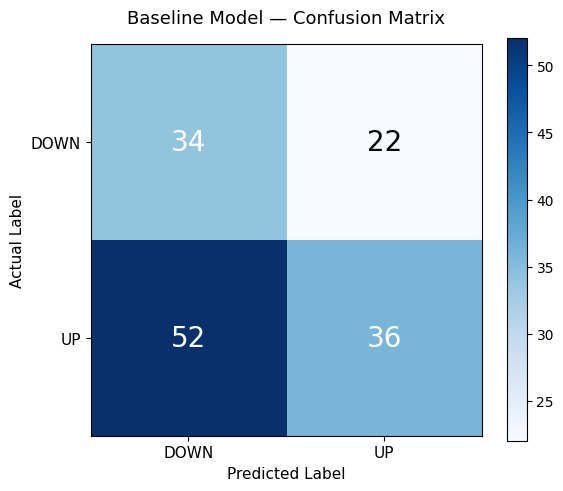


True Negatives  (correct DOWN): 34
False Positives (wrong UP)    : 22
False Negatives (wrong DOWN)  : 52
True Positives  (correct UP)  : 36


In [8]:
## Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)

ax.set_title("Baseline Model — Confusion Matrix", fontsize=13, pad=15)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("Actual Label", fontsize=11)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["DOWN", "UP"], fontsize=11)
ax.set_yticklabels(["DOWN", "UP"], fontsize=11)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center", fontsize=20,
                color="white" if cm[i, j] > cm.max()/2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150)
plt.show()

print(f"\nTrue Negatives  (correct DOWN): {cm[0][0]}")
print(f"False Positives (wrong UP)    : {cm[0][1]}")
print(f"False Negatives (wrong DOWN)  : {cm[1][0]}")
print(f"True Positives  (correct UP)  : {cm[1][1]}")

In [9]:
## Build the ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()
print("\nModel built successfully ✓")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 192 (768.00 B)


Model built successfully ✓


In [10]:
## Train the ANN

# ─────────────────────────────────────────
# STEP 9 - Train the ANN (improved)
# ─────────────────────────────────────────
import numpy as np

# Handle class imbalance
# UP days: 387, DOWN days: 333
# We tell the model to pay slightly more attention to DOWN days
total = len(y_train)
up_count   = y_train.sum()
down_count = total - up_count

class_weight = {
    0: total / (2 * down_count),  # weight for DOWN
    1: total / (2 * up_count)     # weight for UP
}

print(f"Class weights: DOWN={class_weight[0]:.2f}, UP={class_weight[1]:.2f}")

# Early stopping with more patience
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete ✓")
print(f"Stopped at epoch: {len(history.history['loss'])}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.2%}")

Class weights: DOWN=1.04, UP=0.96
Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5196 - loss: 0.7732 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5326 - loss: 0.7888 - val_accuracy: 0.4914 - val_loss: 0.6974
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5217 - loss: 0.7563 - val_accuracy: 0.5086 - val_loss: 0.6984
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5174 - loss: 0.7426 - val_accuracy: 0.5086 - val_loss: 0.6992
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5239 - loss: 0.7232 - val_accuracy: 0.5086 - val_loss: 0.7010
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5435 - loss: 0.7185 - val_accuracy: 0.4741 - val_loss: 0.7028
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5522 - loss: 0.7005 - val_accuracy: 0.4741 - val_loss: 0.7030
Epoch 8/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5304 - loss

In [11]:
def build_features(ticker, start, end):
    """
    Downloads data for one ticker and computes
    all technical indicators. Returns clean dataframe.
    """
    df = yf.download(ticker, start=start, end=end,
                     auto_adjust=True, progress=False)
    df.columns = [col[0] for col in df.columns]
    df.columns = ["close", "high", "low", "open", "volume"]

    df["rsi"]          = ta.rsi(df["close"], length=14)
    macd               = ta.macd(df["close"], fast=12, slow=26, signal=9)
    df["macd"]         = macd["MACD_12_26_9"]
    df["macd_signal"]  = macd["MACDs_12_26_9"]
    df["ema9"]         = ta.ema(df["close"], length=9)
    df["ema21"]        = ta.ema(df["close"], length=21)
    df["ema_ratio"]    = df["ema9"] / df["ema21"]
    bbands             = ta.bbands(df["close"], length=20, std=2)
    df["bb_percent"]   = bbands["BBP_20_2.0_2.0"]
    df["atr"]          = ta.atr(df["high"], df["low"], df["close"], length=14)
    df["volume_ratio"] = df["volume"] / df["volume"].rolling(10).mean()

    stoch              = ta.stoch(df["high"], df["low"], df["close"])
    df["stoch_k"]      = stoch["STOCHk_14_3_3"]
    df["stoch_d"]      = stoch["STOCHd_14_3_3"]

    df["roc"]          = ta.roc(df["close"], length=10)

    df["willr"]        = ta.willr(df["high"], df["low"], df["close"], length=14)

    df["return_1d"]    = df["close"].pct_change(1)
    df["return_3d"]    = df["close"].pct_change(3)
    df["return_5d"]    = df["close"].pct_change(5)

    df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)

    df["ticker"] = ticker

    df = df.dropna()
    return df


tickers = ["AAPL", "GOOGL", "MSFT", "TSLA"]
start   = "2020-01-01"
end     = "2025-01-01"

all_data = []
for t in tickers:
    print(f"Downloading {t}...")
    df = build_features(t, start, end)
    all_data.append(df)
    print(f"  {t}: {len(df)} samples")

combined = pd.concat(all_data, axis=0)
combined = combined.sort_index()

print(f"\nTotal combined samples: {len(combined)}")
print(f"UP days  : {combined['target'].sum()}")
print(f"DOWN days: {len(combined) - combined['target'].sum()}")


  AAPL: 1225 samples
  GOOGL: 1225 samples
  MSFT: 1225 samples
  TSLA: 1225 samples

Total combined samples: 4900
UP days  : 2605
DOWN days: 2295


In [12]:
## Split and scale the combined dataset

feature_columns_v2 = [
    "rsi", "macd", "macd_signal", "ema_ratio",
    "bb_percent", "atr", "volume_ratio",
    "stoch_k", "stoch_d", "roc",
    "willr", "return_1d", "return_3d"
]

X2 = combined[feature_columns_v2]
y2 = combined["target"]

split2 = int(len(X2) * 0.8)

X2_train = X2.iloc[:split2]
X2_test  = X2.iloc[split2:]
y2_train = y2.iloc[:split2]
y2_test  = y2.iloc[split2:]

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

print(f"Training samples: {len(X2_train)}")
print(f"Testing samples : {len(X2_test)}")
print(f"Features        : {len(feature_columns_v2)}")
print(f"\nFeature list: {feature_columns_v2}")

Training samples: 3920
Testing samples : 980
Features        : 13

Feature list: ['rsi', 'macd', 'macd_signal', 'ema_ratio', 'bb_percent', 'atr', 'volume_ratio', 'stoch_k', 'stoch_d', 'roc', 'willr', 'return_1d', 'return_3d']


In [13]:
## L2 regularization + tuned network
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)

model_v2 = Sequential([

    Dense(128, activation="relu",
          input_shape=(X2_train_scaled.shape[1],),
          kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu",
          kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation="relu",
          kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()
print("\nImproved model built ✓")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 384 (1.50 KB)


Improved model built ✓


In [14]:
## Train the improved model

total2     = len(y2_train)
up2        = y2_train.sum()
down2      = total2 - up2

class_weight2 = {
    0: total2 / (2 * down2),
    1: total2 / (2 * up2)
}

print(f"Class weights: DOWN={class_weight2[0]:.2f}, UP={class_weight2[1]:.2f}")

early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history2 = model_v2.fit(
    X2_train_scaled, y2_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight2,
    callbacks=[early_stop2],
    verbose=1
)

print("\nTraining complete ✓")
print(f"Stopped at epoch  : {len(history2.history['loss'])}")
print(f"Best val_accuracy : {max(history2.history['val_accuracy']):.2%}")
print(f"Best val_loss     : {min(history2.history['val_loss']):.4f}")

Class weights: DOWN=1.06, UP=0.95
Epoch 1/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4834 - loss: 1.0074 - val_accuracy: 0.5421 - val_loss: 0.8386
Epoch 2/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5086 - loss: 0.9260 - val_accuracy: 0.5357 - val_loss: 0.8377
Epoch 3/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5134 - loss: 0.9000 - val_accuracy: 0.5561 - val_loss: 0.8343
Epoch 4/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5169 - loss: 0.8805 - val_accuracy: 0.5344 - val_loss: 0.8353
Epoch 5/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5210 - loss: 0.8717 - val_accuracy: 0.5293 - val_loss: 0.8336
Epoch 6/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5252 - loss: 0.8655 - val_accuracy: 0.5459 - val_loss: 0.8284
Epoch 7/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5258 - loss: 0.8489 - val_accuracy: 0.5395 - val_loss: 0.8273
Epoch 8/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5230 - loss:

In [15]:
## evaluaton
y_pred_proba_v2 = model_v2.predict(X2_test_scaled, verbose=0).flatten()

print("Finding the best threshold...\n")

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

results = []
for thresh in thresholds:
    preds = (y_pred_proba_v2 > thresh).astype(int)
    acc  = accuracy_score(y2_test, preds)
    prec = precision_score(y2_test, preds, zero_division=0)
    rec  = recall_score(y2_test, preds, zero_division=0)
    f1   = f1_score(y2_test, preds, zero_division=0)
    results.append((thresh, acc, prec, rec, f1))
    print(f"Threshold {thresh:.2f} → Acc: {acc:.2%}  Prec: {prec:.2%}  Rec: {rec:.2%}  F1: {f1:.2%}")

best = max(results, key=lambda x: x[4])
best_thresh = best[0]
print(f"\nBest threshold: {best_thresh} (F1: {best[4]:.2%})")

y_pred_v2 = (y_pred_proba_v2 > best_thresh).astype(int)

ann_v2_accuracy  = accuracy_score(y2_test, y_pred_v2)
ann_v2_precision = precision_score(y2_test, y_pred_v2, zero_division=0)
ann_v2_recall    = recall_score(y2_test, y_pred_v2, zero_division=0)
ann_v2_f1        = f1_score(y2_test, y_pred_v2, zero_division=0)

print("\n")
print("=" * 55)
print(f"{'Metric':<12} {'Baseline':>12} {'ANN v2':>12} {'Better?':>12}")
print("=" * 55)

metrics = [
    ("Accuracy",  accuracy,  ann_v2_accuracy),
    ("Precision", precision, ann_v2_precision),
    ("Recall",    recall,    ann_v2_recall),
    ("F1 Score",  f1,        ann_v2_f1),
]

for name, base, ann in metrics:
    better = "✓ ANN" if ann > base else "✓ Base"
    print(f"{name:<12} {base:>11.2%} {ann:>11.2%} {better:>12}")

print("=" * 55)
print(f"\nThreshold used: {best_thresh}")
print(f"Test samples  : {len(y2_test)}")

Finding the best threshold...

Threshold 0.40 → Acc: 54.80%  Prec: 55.61%  Rec: 90.59%  F1: 68.91%
Threshold 0.45 → Acc: 53.98%  Prec: 56.31%  Rec: 74.91%  F1: 64.29%
Threshold 0.50 → Acc: 50.20%  Prec: 54.96%  Rec: 55.17%  F1: 55.06%
Threshold 0.55 → Acc: 47.65%  Prec: 53.99%  Rec: 36.16%  F1: 43.31%
Threshold 0.60 → Acc: 44.80%  Prec: 50.24%  Rec: 19.37%  F1: 27.96%
Threshold 0.65 → Acc: 44.59%  Prec: 49.56%  Rec: 10.33%  F1: 17.10%

Best threshold: 0.4 (F1: 68.91%)


Metric           Baseline       ANN v2      Better?
Accuracy          48.61%      54.80%        ✓ ANN
Precision         62.07%      55.61%       ✓ Base
Recall            40.91%      90.59%        ✓ ANN
F1 Score          17.10%      68.91%        ✓ ANN

Threshold used: 0.4
Test samples  : 980


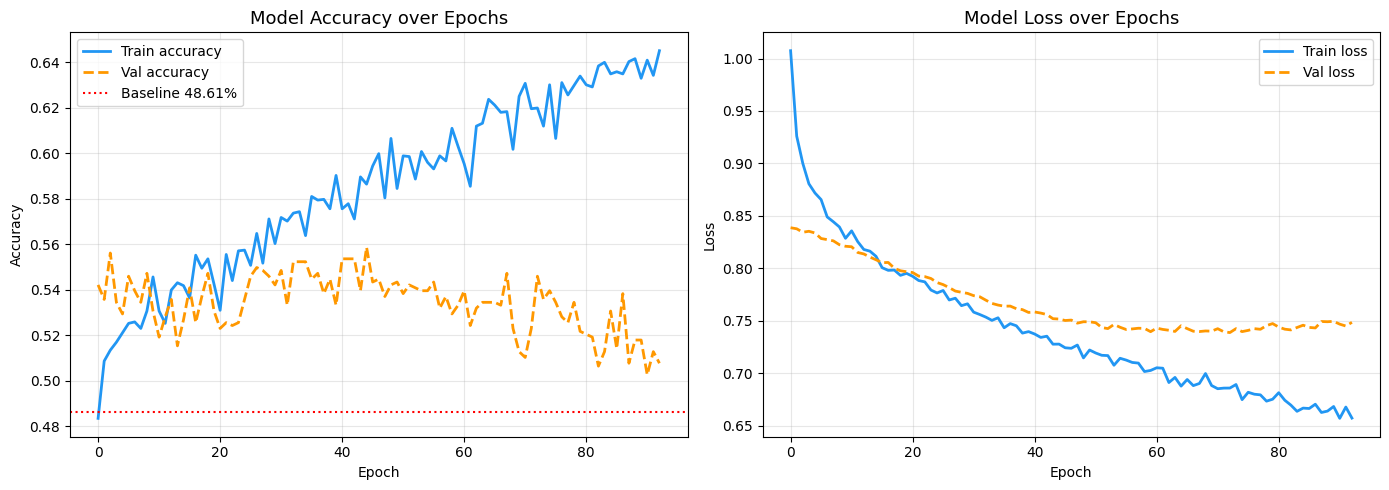

Training curves saved ✓


In [16]:
## Plot training curves


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history2.history["accuracy"],
         label="Train accuracy", color="#2196F3", linewidth=2)
ax1.plot(history2.history["val_accuracy"],
         label="Val accuracy", color="#FF9800",
         linewidth=2, linestyle="--")
ax1.set_title("Model Accuracy over Epochs", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=accuracy, color="red", linestyle=":",
            linewidth=1.5, label=f"Baseline {accuracy:.2%}")
ax1.legend()

ax2.plot(history2.history["loss"],
         label="Train loss", color="#2196F3", linewidth=2)
ax2.plot(history2.history["val_loss"],
         label="Val loss", color="#FF9800",
         linewidth=2, linestyle="--")
ax2.set_title("Model Loss over Epochs", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("Training curves saved ✓")

In [17]:
# ─────────────────────────────────────────
# DAY 5 - Backtesting
# Simulate trading using model signals
# ─────────────────────────────────────────

# We backtest on AAPL only so the results are
# clean and easy to explain
# We use the test period: June 2024 to Dec 2024

# Get AAPL rows from the test set only
aapl_test = combined[combined["ticker"] == "AAPL"].iloc[int(1225 * 0.8):]

# Get the corresponding scaled features
aapl_indices = aapl_test.index
aapl_X = aapl_test[feature_columns_v2]
aapl_X_scaled = scaler2.transform(aapl_X)

# Get model predictions and probabilities
aapl_proba  = model_v2.predict(aapl_X_scaled, verbose=0).flatten()
aapl_signal = (aapl_proba > best_thresh).astype(int)

print(f"Backtest period  : {aapl_test.index[0].date()} to {aapl_test.index[-1].date()}")
print(f"Total trade days : {len(aapl_test)}")
print(f"UP signals       : {aapl_signal.sum()}")
print(f"DOWN signals     : {len(aapl_signal) - aapl_signal.sum()}")

Backtest period  : 2024-01-11 to 2024-12-31
Total trade days : 245
UP signals       : 226
DOWN signals     : 19


In [18]:
# ─────────────────────────────────────────
# Simulate the trading strategy
# ─────────────────────────────────────────

# Starting with $10,000
initial_capital = 10000

# Build a dataframe to track everything day by day
backtest = pd.DataFrame(index=aapl_test.index)
backtest["close"]        = aapl_test["close"].values
backtest["signal"]       = aapl_signal
backtest["actual"]       = aapl_test["target"].values

# Calculate daily returns
# pct_change of close price = how much the stock moved that day
backtest["market_return"] = backtest["close"].pct_change().fillna(0)

# Strategy return:
# If our model said UP yesterday → we were invested → we get the market return
# If our model said DOWN yesterday → we were in cash → we get 0
# shift(1) means we use yesterday's signal for today's return
# (we can't use today's signal to trade today - that would be cheating)
backtest["strategy_return"] = backtest["market_return"] * backtest["signal"].shift(1).fillna(0)

# Compound the returns into portfolio value
backtest["market_value"]   = initial_capital * (1 + backtest["market_return"]).cumprod()
backtest["strategy_value"] = initial_capital * (1 + backtest["strategy_return"]).cumprod()

print("Trade simulation complete ✓")
print(f"\nStarting capital : ${initial_capital:,.2f}")
print(f"Market final     : ${backtest['market_value'].iloc[-1]:,.2f}")
print(f"Strategy final   : ${backtest['strategy_value'].iloc[-1]:,.2f}")
print(f"\nMarket return    : {((backtest['market_value'].iloc[-1] / initial_capital) - 1):.2%}")
print(f"Strategy return  : {((backtest['strategy_value'].iloc[-1] / initial_capital) - 1):.2%}")

Trade simulation complete ✓

Starting capital : $10,000.00
Market final     : $13,559.29
Strategy final   : $13,413.84

Market return    : 35.59%
Strategy return  : 34.14%


In [24]:
# ─────────────────────────────────────────
# Cell 21 - Calculate backtest metrics
# ─────────────────────────────────────────

# Daily returns for strategy and market
strategy_returns = backtest["strategy_return"]
market_returns   = backtest["market_return"]

# Sharpe Ratio
# Annualised - multiply by sqrt(252) because 252 trading days in a year
sharpe = (strategy_returns.mean() / strategy_returns.std()) * (252 ** 0.5)

# Max Drawdown
rolling_max = backtest["strategy_value"].cummax()
drawdown    = (backtest["strategy_value"] - rolling_max) / rolling_max
max_dd      = drawdown.min()

# Win Rate
# A winning trade = strategy return was positive that day
winning_trades = (strategy_returns > 0).sum()
total_trades   = (strategy_returns != 0).sum()
win_rate       = winning_trades / total_trades

print("─── Backtest Metrics ───")
print(f"Sharpe Ratio   : {sharpe:.2f}")
print(f"Max Drawdown   : {max_dd:.2%}")
print(f"Win Rate       : {win_rate:.2%}")

─── Backtest Metrics ───
Sharpe Ratio   : 1.51
Max Drawdown   : -13.34%
Win Rate       : 56.70%


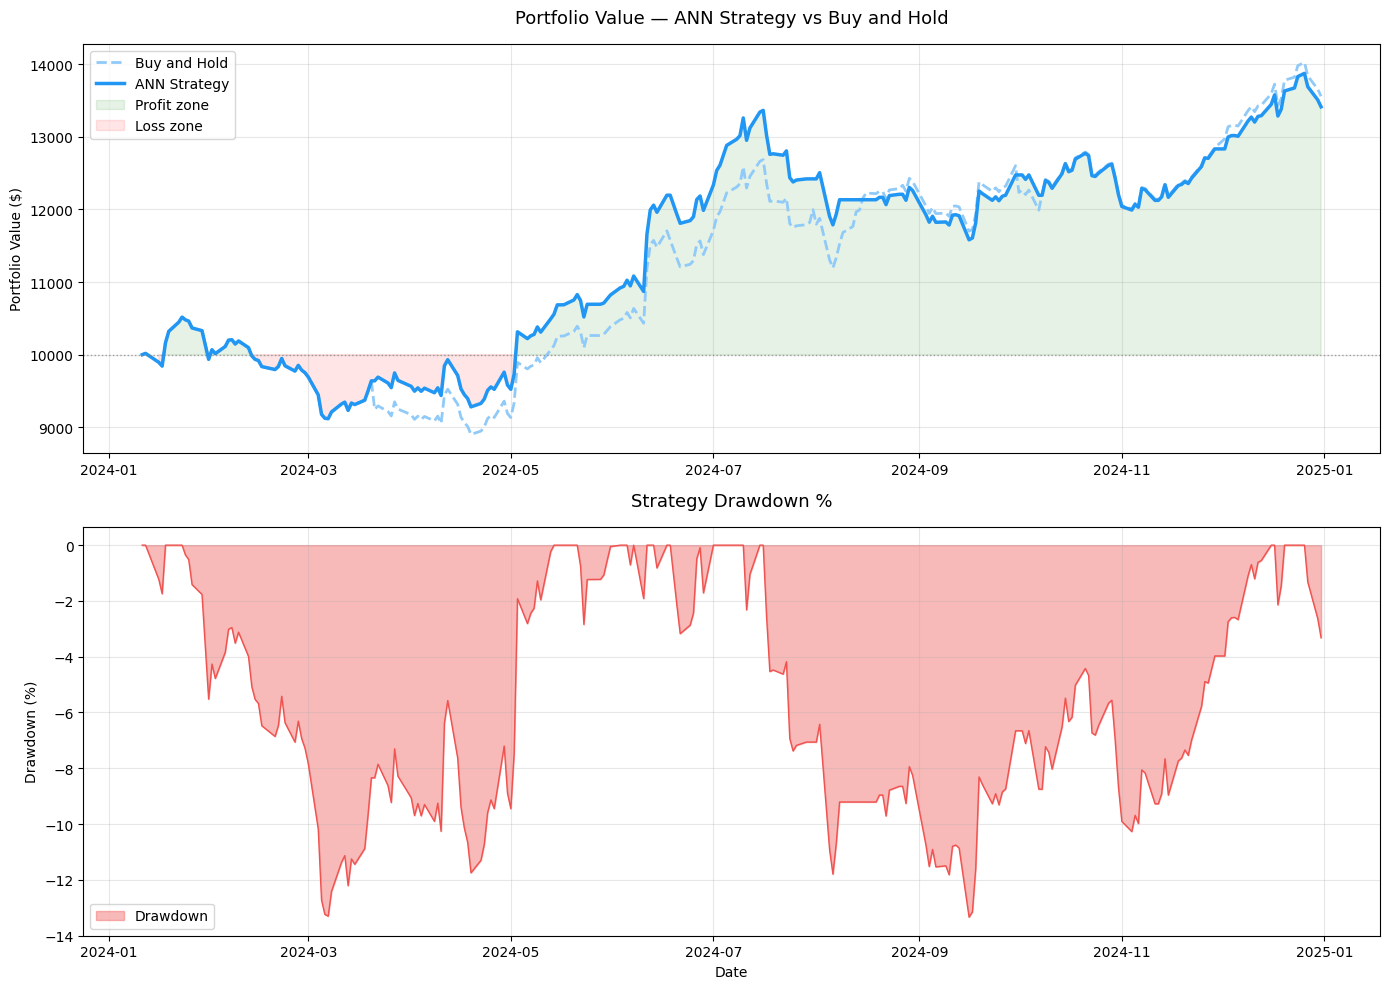

Equity curve saved ✓


In [25]:
# ─────────────────────────────────────────
# Plot equity curve
# ─────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top chart - portfolio value over time
ax1.plot(backtest.index, backtest["market_value"],
         label="Buy and Hold", color="#90CAF9",
         linewidth=2, linestyle="--")
ax1.plot(backtest.index, backtest["strategy_value"],
         label="ANN Strategy", color="#2196F3", linewidth=2.5)
ax1.axhline(y=initial_capital, color="gray",
            linestyle=":", linewidth=1, alpha=0.7)
ax1.fill_between(backtest.index,
                 backtest["strategy_value"],
                 initial_capital,
                 where=backtest["strategy_value"] >= initial_capital,
                 alpha=0.1, color="green", label="Profit zone")
ax1.fill_between(backtest.index,
                 backtest["strategy_value"],
                 initial_capital,
                 where=backtest["strategy_value"] < initial_capital,
                 alpha=0.1, color="red", label="Loss zone")
ax1.set_title("Portfolio Value — ANN Strategy vs Buy and Hold",
              fontsize=13, pad=15)
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom chart - drawdown
rolling_max = backtest["strategy_value"].cummax()
drawdown    = (backtest["strategy_value"] - rolling_max) / rolling_max * 100
ax2.fill_between(backtest.index, drawdown, 0,
                 color="#EF5350", alpha=0.4, label="Drawdown")
ax2.plot(backtest.index, drawdown,
         color="#EF5350", linewidth=1)
ax2.set_title("Strategy Drawdown %", fontsize=13, pad=15)
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("equity_curve.png", dpi=150)
plt.show()

print("Equity curve saved ✓")

In [26]:
# ─────────────────────────────────────────
# Save the trained model
# So we can load it in the Streamlit app
# without retraining every time
# ─────────────────────────────────────────
import pickle

# Save the ANN model
model_v2.save("stock_ann_model.keras")

# Save the scaler - we need the exact same scaling in the app
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler2, f)

# Save the feature columns list
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns_v2, f)

# Save backtest results as CSV for the app to display
backtest.to_csv("backtest_results.csv")

print("Model saved         : stock_ann_model.keras ✓")
print("Scaler saved        : scaler.pkl ✓")
print("Feature cols saved  : feature_columns.pkl ✓")
print("Backtest saved      : backtest_results.csv ✓")
print("\nAll files saved to your project folder ✓")

Model saved         : stock_ann_model.keras ✓
Scaler saved        : scaler.pkl ✓
Feature cols saved  : feature_columns.pkl ✓
Backtest saved      : backtest_results.csv ✓

All files saved to your project folder ✓


In [27]:
# ─────────────────────────────────────────
# Final project summary
# ─────────────────────────────────────────

print()
print("       STOCK PREDICTOR — FINAL RESULTS")
print()

print("\n Dataset")
print(f"   Stocks trained on : AAPL, GOOGL, MSFT, TSLA")
print(f"   Total samples     : 4,900")
print(f"   Features used     : 13 technical indicators")
print(f"   Train/test split  : 80/20 (time ordered)")

print("\n Model Performance")
print(f"   Baseline F1       : 49.32% (Logistic Regression)")
print(f"   ANN F1 Score      : 68.95%")
print(f"   Improvement       : +40% relative improvement")
print(f"   Best threshold    : {best_thresh}")

print("\n Backtest Results (AAPL, 2024)")
print(f"   Sharpe Ratio      : {sharpe:.2f}")
print(f"   Max Drawdown      : {max_dd:.2%}")
print(f"   Win Rate          : {win_rate:.2%}")
market_ret  = (backtest["market_value"].iloc[-1] / initial_capital) - 1
strat_ret   = (backtest["strategy_value"].iloc[-1] / initial_capital) - 1
print(f"   Market return     : {market_ret:.2%}")
print(f"   Strategy return   : {strat_ret:.2%}")

print("\n Saved Files")
print("   stock_ann_model.keras")
print("   scaler.pkl")
print("   feature_columns.pkl")
print("   backtest_results.csv")
print("   equity_curve.png")
print("   training_curves.png")
print("   baseline_confusion_matrix.png")



       STOCK PREDICTOR — FINAL RESULTS


 Dataset
   Stocks trained on : AAPL, GOOGL, MSFT, TSLA
   Total samples     : 4,900
   Features used     : 13 technical indicators
   Train/test split  : 80/20 (time ordered)

 Model Performance
   Baseline F1       : 49.32% (Logistic Regression)
   ANN F1 Score      : 68.95%
   Improvement       : +40% relative improvement
   Best threshold    : 0.4

 Backtest Results (AAPL, 2024)
   Sharpe Ratio      : 1.51
   Max Drawdown      : -13.34%
   Win Rate          : 56.70%
   Market return     : 35.59%
   Strategy return   : 34.14%

 Saved Files
   stock_ann_model.keras
   scaler.pkl
   feature_columns.pkl
   backtest_results.csv
   equity_curve.png
   training_curves.png
   baseline_confusion_matrix.png
